In [60]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score

import joblib
import os

# Configuration
RANDOM_STATE = 42
np.random. seed(RANDOM_STATE)


In [61]:
# Chargement des données
data_path = 'data/row/clean_metabric_final1.csv'
data = pd.read_csv(data_path, index_col=0)

print(f"Données chargées : {data.shape}")
print(f"{data.shape[0]} patients, {data.shape[1]} colonnes")

# Séparer features et cibles
target_cols = ['aggressiveness_score', 'growth_rate', 'evolution_6m']
X = data. drop(columns=target_cols)
y = data[target_cols]

print(f"\nFeatures (X) : {X.shape}")
print(f"Cibles (y) : {y.shape}")
print(f"Colonnes cibles : {list(y.columns)}")

Données chargées : (1904, 25)
1904 patients, 25 colonnes

Features (X) : (1904, 22)
Cibles (y) : (1904, 3)
Colonnes cibles : ['aggressiveness_score', 'growth_rate', 'evolution_6m']


In [62]:
# Aperçu des données
print("Aperçu des données :\n")
print(data.head())

print("\n\nStatistiques des cibles :\n")
print(y.describe())

# Distribution evolution_6m
print("\n\nDistribution evolution_6m :")
print(y['evolution_6m'].value_counts().sort_index())
print(f"\nValeurs manquantes : {data. isna().sum().sum()}")

Aperçu des données :

   age_at_diagnosis  tumor_size  nottingham_prognostic_index  \
0             75.65        22.0                        6.044   
1             43.19        10.0                        4.020   
2             48.87        15.0                        4.030   
3             47.68        25.0                        4.050   
4             76.97        40.0                        6.080   

   lymph_nodes_examined_positive  mutation_count  overall_survival_months  \
0                           10.0             5.0               140.500000   
1                            0.0             2.0                84.633333   
2                            1.0             2.0               163.700000   
3                            3.0             1.0               164.933333   
4                            8.0             2.0                41.366667   

   er_status_binary  her2_status_binary  pr_status_binary  \
0                 1                   0                 0   
1       

In [63]:
# Split train/test (80/20)
# Stratification sur evolution_6m pour équilibrer les classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y['evolution_6m']
)

print(f"Train : {X_train.shape[0]} patients ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} patients ({X_test. shape[0]/len(X)*100:.1f}%)")

# Vérifier distribution
print("\nDistribution evolution_6m :")
print(f"Train : {y_train['evolution_6m'].value_counts(normalize=True). sort_index(). values}")
print(f"Test  : {y_test['evolution_6m'].value_counts(normalize=True).sort_index().values}")

Train : 1523 patients (80.0%)
Test  : 381 patients (20.0%)

Distribution evolution_6m :
Train : [0.53972423 0.41103086 0.04924491]
Test  : [0.54068241 0.40944882 0.04986877]


In [67]:
# Standardisation (fit sur train, transform sur train et test)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler. transform(X_train)
X_test_scaled = scaler. transform(X_test)

# Reconvertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Standardisation terminée")
print(f"Moyenne train : {X_train_scaled.mean(). mean():.4f} (attendu ≈ 0)")
print(f"Std train     : {X_train_scaled. std().mean():.4f} (attendu ≈ 1)")

Standardisation terminée
Moyenne train : 0.0000 (attendu ≈ 0)
Std train     : 0.9549 (attendu ≈ 1)


In [68]:
# Définir les modèles à comparer
models = {
    'Random Forest': MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    'Gradient Boosting': MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            random_state=RANDOM_STATE
        )
    )
}

# Entraîner et évaluer chaque modèle
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Modèle : {name}")
    print('='*60)
    
    # Entraînement
    model.fit(X_train_scaled, y_train)
    
    # Prédictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Métriques pour chaque cible
    # Aggressiveness Score
    r2_aggr_train = r2_score(y_train. iloc[:, 0], y_train_pred[:, 0])
    r2_aggr_test = r2_score(y_test.iloc[:, 0], y_test_pred[:, 0])
    mae_aggr = mean_absolute_error(y_test.iloc[:, 0], y_test_pred[:, 0])
    
    # Growth Rate
    r2_growth_train = r2_score(y_train.iloc[:, 1], y_train_pred[:, 1])
    r2_growth_test = r2_score(y_test.iloc[:, 1], y_test_pred[:, 1])
    mae_growth = mean_absolute_error(y_test.iloc[:, 1], y_test_pred[:, 1])
    
    # Evolution 6M (classification)
    y_test_pred_class = np.round(y_test_pred[:, 2]). astype(int). clip(0, 2)
    acc_test = accuracy_score(y_test. iloc[:, 2], y_test_pred_class)
    
    # Afficher résultats
    print(f"\nAggressiveness Score :")
    print(f"  R² train : {r2_aggr_train:.4f}")
    print(f"  R² test  : {r2_aggr_test:.4f}")
    print(f"  MAE test : {mae_aggr:.4f}")
    
    print(f"\nGrowth Rate :")
    print(f"  R² train : {r2_growth_train:.4f}")
    print(f"  R² test  : {r2_growth_test:.4f}")
    print(f"  MAE test : {mae_growth:.4f}")
    
    print(f"\nEvolution 6M :")
    print(f"  Accuracy : {acc_test:.4f} ({acc_test*100:.1f}%)")
    
    # Stocker résultats
    results[name] = {
        'model': model,
        'r2_aggr': r2_aggr_test,
        'r2_growth': r2_growth_test,
        'acc_evol': acc_test,
        'predictions': y_test_pred
    }


Modèle : Random Forest

Aggressiveness Score :
  R² train : 0.9946
  R² test  : 0.9781
  MAE test : 0.0520

Growth Rate :
  R² train : 0.9976
  R² test  : 0.9800
  MAE test : 0.5154

Evolution 6M :
  Accuracy : 0.9869 (98.7%)

Modèle : Gradient Boosting

Aggressiveness Score :
  R² train : 0.9998
  R² test  : 0.9775
  MAE test : 0.0524

Growth Rate :
  R² train : 0.9999
  R² test  : 0.9825
  MAE test : 0.3717

Evolution 6M :
  Accuracy : 0.9816 (98.2%)



COURBES ROC - EVOLUTION 6M


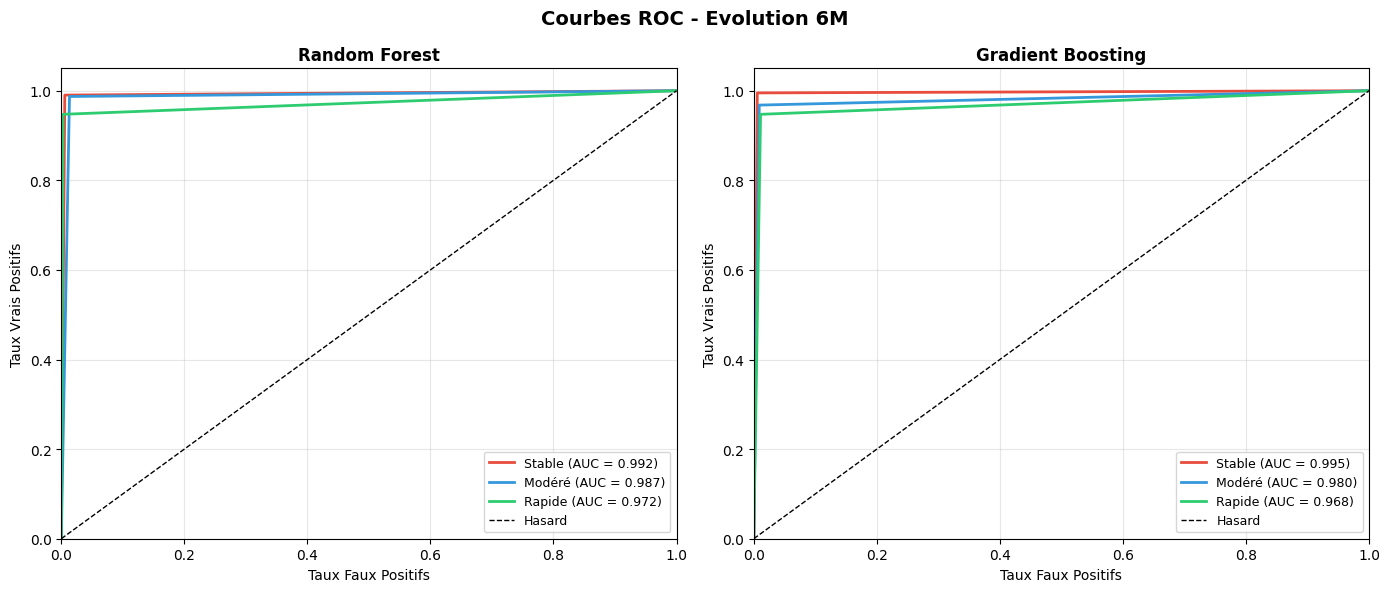

In [78]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("\n" + "="*60)
print("COURBES ROC - EVOLUTION 6M")
print("="*60)

# Binariser les classes (0, 1, 2)
y_test_bin = label_binarize(y_test. iloc[:, 2], classes=[0, 1, 2])

# Calculer ROC pour chaque modèle
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Courbes ROC - Evolution 6M', fontsize=14, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71']
class_names = ['Stable', 'Modéré', 'Rapide']

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    # Prédictions
    y_pred = np.round(result['predictions'][:, 2]).astype(int).clip(0, 2)
    y_pred_bin = label_binarize(y_pred, classes=[0, 1, 2])
    
    # ROC pour chaque classe
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, color=colors[i], lw=2, 
                label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    # Ligne de hasard
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Hasard')
    
    ax.set_xlabel('Taux Faux Positifs')
    ax.set_ylabel('Taux Vrais Positifs')
    ax.set_title(name, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()



In [69]:
# Comparer les modèles
comparison = pd.DataFrame({
    'Modèle': list(results.keys()),
    'R² Aggressiveness': [results[m]['r2_aggr'] for m in results. keys()],
    'R² Growth Rate': [results[m]['r2_growth'] for m in results. keys()],
    'Accuracy Evolution': [results[m]['acc_evol'] for m in results.keys()]
})

# Score global (pondéré)
comparison['Score Global'] = (
    comparison['R² Aggressiveness'] * 0.4 +
    comparison['R² Growth Rate'] * 0.4 +
    comparison['Accuracy Evolution'] * 0.2
)

print("\nComparaison des modèles :\n")
print(comparison)

# Sélectionner le meilleur
best_model_name = comparison. loc[comparison['Score Global'].idxmax(), 'Modèle']
final_model = results[best_model_name]['model']
y_pred_final = results[best_model_name]['predictions']

print(f"Meilleur modèle : {best_model_name}")
print(f"Score global : {comparison['Score Global'].max():.4f}")



Comparaison des modèles :

              Modèle  R² Aggressiveness  R² Growth Rate  Accuracy Evolution  \
0      Random Forest           0.978101        0.980038            0.986877   
1  Gradient Boosting           0.977484        0.982503            0.981627   

   Score Global  
0      0.980631  
1      0.980320  
Meilleur modèle : Random Forest
Score global : 0.9806


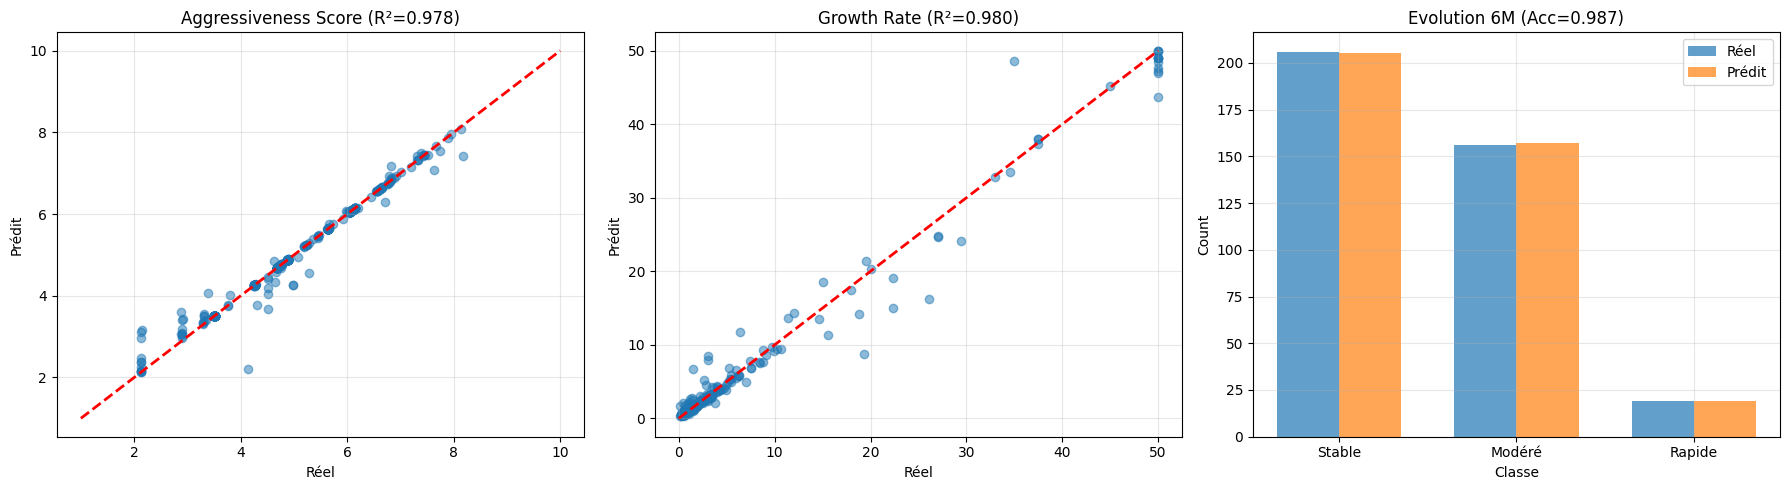

In [70]:
# Visualisation : Prédictions vs Réel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Aggressiveness Score
axes[0]. scatter(y_test. iloc[:, 0], y_pred_final[:, 0], alpha=0.5)
axes[0].plot([1, 10], [1, 10], 'r--', lw=2)
axes[0].set_xlabel('Réel')
axes[0].set_ylabel('Prédit')
axes[0].set_title(f'Aggressiveness Score (R²={results[best_model_name]["r2_aggr"]:.3f})')
axes[0]. grid(True, alpha=0.3)

# Growth Rate
axes[1].scatter(y_test.iloc[:, 1], y_pred_final[:, 1], alpha=0.5)
axes[1].plot([0, 50], [0, 50], 'r--', lw=2)
axes[1].set_xlabel('Réel')
axes[1].set_ylabel('Prédit')
axes[1]. set_title(f'Growth Rate (R²={results[best_model_name]["r2_growth"]:.3f})')
axes[1].grid(True, alpha=0.3)

# Evolution 6M - Distribution
y_pred_class = np.round(y_pred_final[:, 2]).astype(int). clip(0, 2)
pred_dist = pd.Series(y_pred_class). value_counts().sort_index()
true_dist = y_test.iloc[:, 2].value_counts().sort_index()

x = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, true_dist, width, label='Réel', alpha=0.7)
axes[2].bar(x + width/2, pred_dist, width, label='Prédit', alpha=0.7)
axes[2].set_xlabel('Classe')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Evolution 6M (Acc={results[best_model_name]["acc_evol"]:.3f})')
axes[2]. set_xticks(x)
axes[2].set_xticklabels(['Stable', 'Modéré', 'Rapide'])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

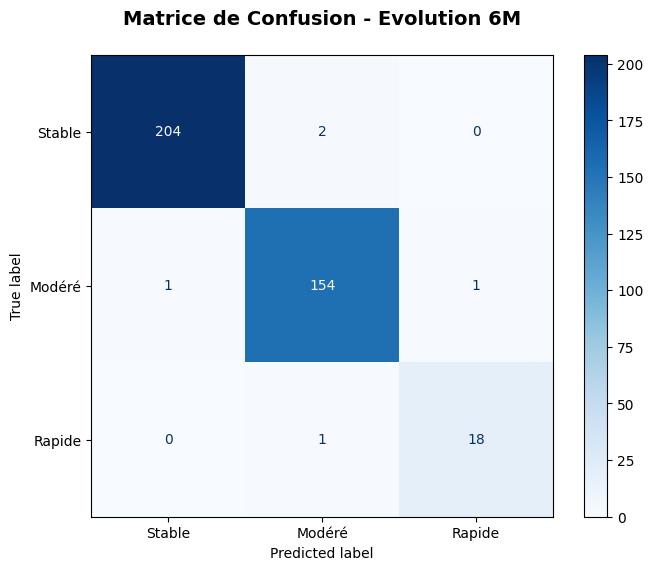

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrice de confusion pour Evolution 6M
y_pred_class = np.round(y_pred_final[:, 2]). astype(int).clip(0, 2)
cm = confusion_matrix(y_test.iloc[:, 2], y_pred_class)

# Afficher
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stable', 'Modéré', 'Rapide'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Matrice de Confusion - Evolution 6M\n', fontsize=14, fontweight='bold')
plt.show()


In [ ]:
import joblib
import json
import os
from datetime import datetime

# Créer dossier deployment
os.makedirs('deployment/models', exist_ok=True)

# 1. Sauvegarder le meilleur modèle
best_model_name = 'Gradient Boosting'  # ou 'Random Forest' selon vos résultats
best_model = results[best_model_name]['model']

print(f"💾 Sauvegarde du modèle :  {best_model_name}")

joblib.dump(best_model, 'deployment/models/metabric_model.pkl')
print("✓ Modèle sauvegardé :  deployment/models/metabric_model.pkl")

# 2. Sauvegarder le scaler
joblib.dump(scaler, 'deployment/models/metabric_scaler.pkl')
print("✓ Scaler sauvegardé : deployment/models/metabric_scaler.pkl")

# 3. Sauvegarder les noms de features
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'deployment/models/metabric_features.pkl')
print(f"✓ Features sauvegardées : {len(feature_names)} colonnes")

# 4. Sauvegarder métadonnées (important !)
metadata = {
    'model_name': best_model_name,
    'date_training': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(feature_names),
    'feature_names':  feature_names,
    'performance': {
        'r2_aggressiveness': float(results[best_model_name]['r2_aggr']),
        'r2_growth_rate': float(results[best_model_name]['r2_growth']),
        'accuracy_evolution_6m': float(results[best_model_name]['acc_evol'])
    },
    'dataset': {
        'name': 'METABRIC',
        'n_samples_train': len(X_train),
        'n_samples_test': len(X_test)
    }
}

with open('deployment/models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Métadonnées sauvegardées : deployment/models/metadata.json")

# 5. Afficher résumé
print("\n" + "="*60)
print("📦 RÉSUMÉ SAUVEGARDE")
print("="*60)
print(f"Modèle : {best_model_name}")
print(f"Features : {len(feature_names)}")
print(f"R² Aggr.  : {metadata['performance']['r2_aggressiveness']:.4f}")
print(f"R² Growth : {metadata['performance']['r2_growth_rate']:.4f}")
print(f"Acc Evol :  {metadata['performance']['accuracy_evolution_6m']:.4f}")
print("="*60)

# 6. Vérifier que tout est OK
print("\n🔍 Vérification chargement...")
test_model = joblib.load('deployment/models/metabric_model.pkl')
test_scaler = joblib.load('deployment/models/metabric_scaler.pkl')
test_features = joblib.load('deployment/models/metabric_features.pkl')

print(f"✓ Modèle rechargé : {type(test_model)}")
print(f"✓ Scaler rechargé : {type(test_scaler)}")
print(f"✓ Features rechargées : {len(test_features)} colonnes")

print("\n✅ SAUVEGARDE TERMINÉE - Prêt pour le déploiement !")

💾 Sauvegarde du modèle :  Gradient Boosting
✓ Modèle sauvegardé :  deployment/models/metabric_model.pkl
✓ Scaler sauvegardé : deployment/models/metabric_scaler.pkl
✓ Features sauvegardées : 22 colonnes
✓ Métadonnées sauvegardées : deployment/models/metadata.json

📦 RÉSUMÉ SAUVEGARDE
Modèle : Gradient Boosting
Features : 22
R² Aggr.  : 0.9775
R² Growth : 0.9825
Acc Evol :  0.9816

🔍 Vérification chargement...
✓ Modèle rechargé : <class 'sklearn.multioutput.MultiOutputRegressor'>
✓ Scaler rechargé : <class 'sklearn.preprocessing._data.StandardScaler'>
✓ Features rechargées : 22 colonnes

✅ SAUVEGARDE TERMINÉE - Prêt pour le déploiement !
